## MultiCaRe dataset Experimentation

In [1]:
from multiversity.multicare_dataset import MedicalDatasetCreator

mdc = MedicalDatasetCreator(directory='medical_datasets')
filters = [
    {'field': 'case_strings', 'string_list': ['PXA', 'xanthoastrocytoma', 'glioma'], 'operator': 'any'},
    {'field': 'label', 'string_list': ['mri', 'head']}
]
# This creates a focused subset for your "Brain Tumor Redirection" test
mdc.create_dataset(dataset_name='pxa_test_set', filter_list=filters, dataset_type='multimodal')


Importing and pre-processing the main files.
Done!
The pxa_test_set was successfully created!


## Test a sample from the MultiCaRe dataset with medgemma model

In [4]:
from transformers import pipeline
from PIL import Image
import requests
import torch
import pandas as pd
import json
import os

pipe = pipeline(
    "image-text-to-text",
    model="google/medgemma-1.5-4b-it",
    torch_dtype=torch.bfloat16,
    device="cuda",
)

print("medgemma-1.5-4b-it loaded successfully")


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda


medgemma-1.5-4b-it loaded successfully


In [5]:
import pandas as pd

# Load the pxa_test_set dataset
dataset_path = 'medical_datasets/pxa_test_set'

# Load cases data
cases_df = pd.read_csv(f'{dataset_path}/cases.csv')
print(f"Total cases: {len(cases_df)}")
print(f"Columns: {cases_df.columns.tolist()}")
print("\nSample cases:")
cases_df.head(3)

Total cases: 727
Columns: ['case_id', 'pmcid', 'gender', 'age', 'case_text']

Sample cases:


,case_id,pmcid,gender,age,case_text
0,PMC9500339_02,PMC9500339,Female,55.0,A 55-year-old woman was admitted with a histor...
1,PMC8437380_01,PMC8437380,Female,30.0,A 30-year-old female presented to our hospital...
2,PMC6925741_01,PMC6925741,Female,62.0,"A 62 year-old-woman, complaining from micturit..."


In [6]:
# Load image metadata
with open(f'{dataset_path}/image_metadata.json', 'r') as f:
    image_metadata = [json.loads(line) for line in f]

print(f"Total images: {len(image_metadata)}")
print("\nSample image metadata:")
image_metadata[0]

Total images: 787

Sample image metadata:


{'file_id': 'file_0000255',
 'file': 'PMC10018421_crn-2023-0015-0001-529741_f1_a_1_4.webp',
 'file_path': 'medical_datasets/pxa_test_set/images/PMC1/PMC10/PMC10018421_crn-2023-0015-0001-529741_f1_a_1_4.webp',
 'main_image': 'PMC10018421_01_crn-2023-0015-0001-529741_f1.jpg',
 'case_id': 'PMC10018421_01',
 'license': 'CC BY-NC',
 'file_size': 7950,
 'split_during_preprocessing': False,
 'caption': 'Mixed cystic-solid pattern of PXA. MR images show multiple cystic lesions and solid masses located in the right cerebellar hemisphere. A; Sagittal view T1-weighted with contrast.',
 'image_type': 'radiology',
 'image_subtype': 'mri',
 'radiology_region': 'head',
 'radiology_region_granular': 'head',
 'radiology_view': 'sagittal',
 'ml_labels_for_supervised_classification': ['head',
  'radiology',
  'sagittal',
  'mri'],
 'gt_labels_for_semisupervised_classification': ['radiology',
  't1',
  'head',
  'sagittal',
  'mri',
  'mass',
  'contrast',
  'spin_echo']}

In [14]:
# Select a sample case with brain MRI for diagnosis prediction
# Filter for head/brain MRI images with glioma-related cases
brain_mri_images = [img for img in image_metadata if 
                   img.get('radiology_region') == 'head' and 
                   img.get('image_subtype') == 'mri']

print(f"Found {len(brain_mri_images)} brain MRI images")

# Get a sample case
sample_image = brain_mri_images[0]
sample_case_id = sample_image['case_id']

# Get ALL images for this case
case_images = [img for img in brain_mri_images if img['case_id'] == sample_case_id]
print(f"Number of brain MRI images available for this case: {len(case_images)}")

# Get the case text (ground truth)
case_info = cases_df[cases_df['case_id'] == sample_case_id].iloc[0]
print(f"\n--- Selected Case: {sample_case_id} ---")
print(f"Patient: {case_info['gender']}, Age: {case_info['age']}")

# Show all available images for this case
print(f"\n--- All {len(case_images)} Images for this Case ---")
for i, img in enumerate(case_images):
    print(f"\nImage {i+1}:")
    print(f"  Caption: {img['caption']}")
    print(f"  View: {img.get('radiology_view', 'N/A')}")
    print(f"  Path: {img['file_path']}")

Found 787 brain MRI images
Number of brain MRI images available for this case: 4

--- Selected Case: PMC10018421_01 ---
Patient: Male, Age: 32.0

--- All 4 Images for this Case ---

Image 1:
  Caption: Mixed cystic-solid pattern of PXA. MR images show multiple cystic lesions and solid masses located in the right cerebellar hemisphere. A; Sagittal view T1-weighted with contrast.
  View: sagittal
  Path: medical_datasets/pxa_test_set/images/PMC1/PMC10/PMC10018421_crn-2023-0015-0001-529741_f1_a_1_4.webp

Image 2:
  Caption: Mixed cystic-solid pattern of PXA. MR images show multiple cystic lesions and solid masses located in the right cerebellar hemisphere. B; Coronal view T1-weighted with contrast.
  View: sagittal
  Path: medical_datasets/pxa_test_set/images/PMC1/PMC10/PMC10018421_crn-2023-0015-0001-529741_f1_b_2_4.webp

Image 3:
  Caption: Mixed cystic-solid pattern of PXA. MR images show multiple cystic lesions and solid masses located in the right cerebellar hemisphere. C; Axial view 

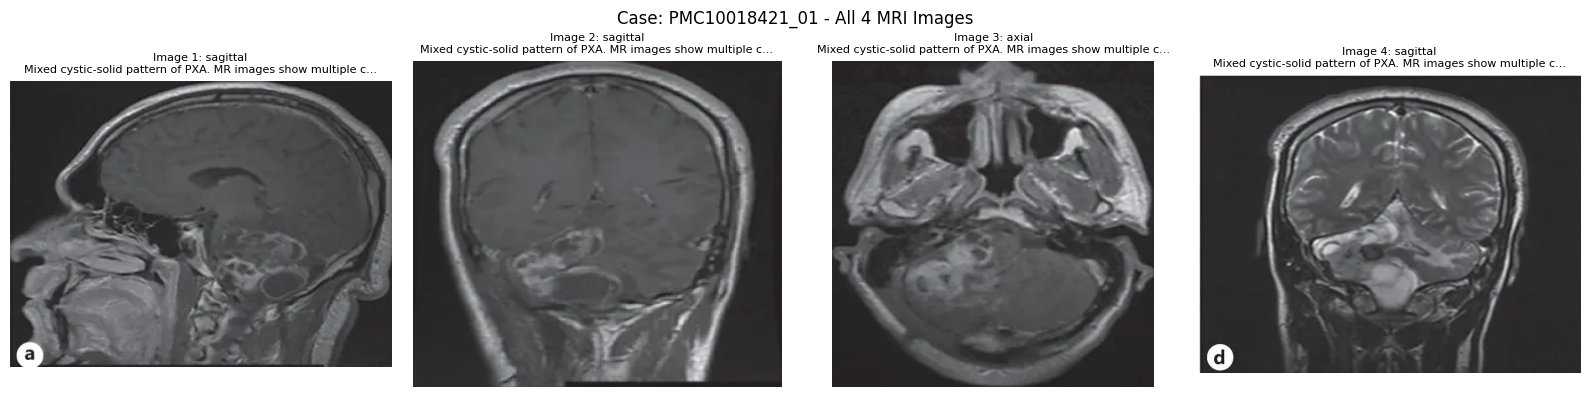


Loaded 4 images for analysis


In [15]:
# Load ALL medical images for this case
import matplotlib.pyplot as plt

loaded_images = []
for img_info in case_images:
    img_path = img_info['file_path']
    img = Image.open(img_path).convert('RGB')
    loaded_images.append({
        'image': img,
        'caption': img_info['caption'],
        'view': img_info.get('radiology_view', 'N/A'),
        'path': img_path
    })

# Display all images in a grid
n_images = len(loaded_images)
cols = min(4, n_images)
rows = (n_images + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
if n_images == 1:
    axes = [axes]
elif rows == 1:
    axes = axes
else:
    axes = axes.flatten()

for i, img_data in enumerate(loaded_images):
    axes[i].imshow(img_data['image'])
    # Truncate caption for display
    caption_short = img_data['caption'][:60] + "..." if len(img_data['caption']) > 60 else img_data['caption']
    axes[i].set_title(f"Image {i+1}: {img_data['view']}\n{caption_short}", fontsize=8)
    axes[i].axis('off')

# Hide empty subplots
for i in range(n_images, len(axes)):
    axes[i].axis('off')

plt.suptitle(f"Case: {sample_case_id} - All {n_images} MRI Images", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nLoaded {n_images} images for analysis")

In [16]:
# Define diagnosis prediction function for MULTIPLE images
def predict_diagnosis_multi_image(images_data, patient_info=None):
    """
    Use MedGemma to analyze multiple medical images and predict possible diagnoses.
    
    Args:
        images_data: List of dicts with 'image', 'caption', 'view' keys
        patient_info: Optional patient information string
    """
    # Build the content list with all images
    content = []
    
    # Add description of what we're providing
    image_descriptions = []
    for i, img_data in enumerate(images_data):
        content.append({"type": "image", "image": img_data['image']})
        image_descriptions.append(f"Image {i+1}: {img_data['view']} view - {img_data['caption']}")
    
    # Build comprehensive prompt for multi-image analysis
    prompt = f"""You are an expert neuroradiologist analyzing a series of {len(images_data)} brain MRI images from the same patient.

The images provided are:
{chr(10).join(image_descriptions)}

Please analyze ALL images together to provide a comprehensive assessment:

1. **Image-by-Image Findings**: Describe the key findings in each image
2. **Integrated Analysis**: Synthesize findings across all images - what do they collectively show?
3. **Key Radiological Features**: 
   - Signal characteristics (T1/T2/FLAIR patterns)
   - Lesion location, size, and extent
   - Mass effect and surrounding edema
   - Enhancement patterns (if contrast images provided)
   - Any cystic or solid components
4. **Differential Diagnosis**: Based on ALL images, list the most likely diagnoses in order of probability
5. **Diagnostic Confidence**: How do multiple views/sequences help narrow the diagnosis?
6. **Recommended Next Steps**: Additional imaging or workup if needed

Be specific and use appropriate medical terminology. Consider how the different views/sequences complement each other.
"""
    
    if patient_info:
        prompt += f"\n\nPatient information: {patient_info}"
    
    content.append({"type": "text", "text": prompt})
    
    # Prepare the message for MedGemma
    messages = [
        {
            "role": "user",
            "content": content
        }
    ]
    
    # Generate prediction with longer output for comprehensive analysis
    output = pipe(text=messages, max_new_tokens=2000)
    response = output[0]["generated_text"][-1]["content"]
    return response

print("✅ Multi-image diagnosis prediction function defined")

✅ Multi-image diagnosis prediction function defined


In [17]:
# Run diagnosis prediction on ALL images for the sample case
patient_info = f"Gender: {case_info['gender']}, Age: {case_info['age']}"

print("=" * 80)
print(f"🔬 MedGemma Multi-Image Diagnosis Prediction ({len(loaded_images)} images)")
print("=" * 80)
print(f"\nPatient: {patient_info}")
print(f"Case ID: {sample_case_id}")
print(f"\nImages being analyzed:")
for i, img_data in enumerate(loaded_images):
    print(f"  {i+1}. {img_data['view']} - {img_data['caption'][:70]}...")
print("\n" + "-" * 80)
print("Analyzing all images together...")
print("-" * 80 + "\n")

# Get the diagnosis prediction using ALL images
prediction = predict_diagnosis_multi_image(loaded_images, patient_info)
print(prediction)

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


🔬 MedGemma Multi-Image Diagnosis Prediction (4 images)

Patient: Gender: Male, Age: 32.0
Case ID: PMC10018421_01

Images being analyzed:
  1. sagittal - Mixed cystic-solid pattern of PXA. MR images show multiple cystic lesi...
  2. sagittal - Mixed cystic-solid pattern of PXA. MR images show multiple cystic lesi...
  3. axial - Mixed cystic-solid pattern of PXA. MR images show multiple cystic lesi...
  4. sagittal - Mixed cystic-solid pattern of PXA. MR images show multiple cystic lesi...

--------------------------------------------------------------------------------
Analyzing all images together...
--------------------------------------------------------------------------------

FINDINGS:

1. **Image-by-Image Findings**:
    *   Image 1 (Sagittal T1 with contrast): Multiple cystic lesions and solid masses are present in the right cerebellar hemisphere. The lesions demonstrate heterogeneous enhancement.
    *   Image 2 (Coronal T1 with contrast): Similar findings as in Image 1, showi

In [18]:
# Compare with ground truth from the case report
print("=" * 80)
print("📋 Ground Truth from Case Report")
print("=" * 80)
print(f"\nCase ID: {sample_case_id}")
print(f"\nCase Summary (first 2000 characters):")
print("-" * 80)
print(case_info['case_text'][:2000])
print("..." if len(case_info['case_text']) > 2000 else "")
print("-" * 80)

📋 Ground Truth from Case Report

Case ID: PMC10018421_01

Case Summary (first 2000 characters):
--------------------------------------------------------------------------------
A 32-year-old male presented with a history of intermittent headache for 5 months followed by progressive gait disturbances and blurry vision. His medical and family history was insignificant. His physical examination showed ataxia and cerebellar signs including dysmetria and dysdiadochokinesia in the right upper and lower limbs. Decreased visual acuity was noted in both eyes with bilateral papilledema on ophthalmologic exam. The rest of the examination was otherwise normal. Brain MRI revealed a lesion in the right cerebellar hemisphere. The patient underwent a suboccipital craniotomy. During the procedure, frozen sections were misinterpreted as high-grade malignant glioma. The neurosurgeon decided to proceed with subtotal resection because the risks of gross total resection (GTR) outweighed the benefits conside

In [19]:
# Use the model to compare its diagnosis with the ground truth
def compare_diagnosis_with_gt(model_prediction, ground_truth_text, patient_info=None):
    """
    Use MedGemma to compare its own diagnosis prediction with the ground truth case report.
    """
    prompt = f"""You are an expert medical AI evaluator. Compare the following AI-generated diagnosis with the ground truth from the actual case report.

## AI Model's Diagnosis Prediction:
{model_prediction}

## Ground Truth from Case Report:
{ground_truth_text}

Please provide a detailed comparison:

1. **Diagnosis Accuracy**: 
   - Did the model correctly identify the primary diagnosis?
   - Were the differential diagnoses appropriate?

2. **Radiological Findings Comparison**:
   - Which findings did the model correctly identify?
   - Were there any findings the model missed?
   - Did the model report any false findings not present in the case?

3. **Clinical Reasoning Assessment**:
   - Was the model's reasoning process sound?
   - Did it appropriately use the imaging features to reach its conclusions?

4. **Overall Score** (out of 10):
   - Provide a numerical score with justification

5. **Summary**:
   - Key strengths of the model's analysis
   - Areas for improvement
"""
    
    if patient_info:
        prompt += f"\n\nPatient information: {patient_info}"
    
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt}
            ]
        }
    ]
    
    output = pipe(text=messages, max_new_tokens=1500)
    response = output[0]["generated_text"][-1]["content"]
    return response

# Run the comparison
print("=" * 80)
print("🔍 Model Self-Evaluation: Comparing Prediction vs Ground Truth")
print("=" * 80)
print("\nAnalyzing comparison...")
print("-" * 80 + "\n")

comparison_result = compare_diagnosis_with_gt(
    model_prediction=prediction,
    ground_truth_text=case_info['case_text'],
    patient_info=patient_info
)
print(comparison_result)

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


🔍 Model Self-Evaluation: Comparing Prediction vs Ground Truth

Analyzing comparison...
--------------------------------------------------------------------------------

## Comparison: AI Model Diagnosis vs. Ground Truth Case Report

**1. Diagnosis Accuracy:**

*   **Primary Diagnosis**:
    *   **AI Model**: Suggests metastatic disease, specifically cerebellar metastases, as the most likely diagnosis.
    *   **Ground Truth**: The actual diagnosis is **Pangliar X-Antigenoma (PXA)**, a benign, slow-growing tumor.
    *   **Comparison**: The AI model's primary diagnosis (metastatic disease) is **incorrect**. The ground truth diagnosis (PXA) is significantly different.
*   **Differential Diagnoses**:
    *   **AI Model**: Includes primary cerebellar tumors (medulloblastoma, ependymoma, hemangioblastoma), abscesses, and cysticercosis.
    *   **Ground Truth**: The case report does not explicitly list differential diagnoses in the same way, but the clinical course (reemergence of symptoms a

In [1]:
import pandas as pd

cases_df = pd.read_csv('medical_datasets/whole_multicare_dataset/captions_and_labels.csv')

# get the rows with image_subtype = x_ray, image_type = radiology, and substring 'chest x-ray' in caption
mask = (
    (cases_df['image_subtype'] == 'x_ray') &
    (cases_df['image_type'] == 'radiology') &
    (cases_df['caption'].str.contains(r'chest\s*x-?ray', case=False, na=False))
)
xray_radiology_cases = cases_df[mask]
print(f"Total X-ray radiology cases: {len(xray_radiology_cases)}")
print("\nSample X-ray radiology cases:")
xray_radiology_cases.head(5)

Total X-ray radiology cases: 956

Sample X-ray radiology cases:


,file_id,file,main_image,image_component,patient_id,license,file_size,caption,case_substring,image_type,image_subtype,radiology_region,radiology_region_granular,radiology_view,ml_labels_for_supervised_classification,gt_labels_for_semisupervised_classification
34,file_0000034,PMC10009052_gr1_undivided_1_1.webp,PMC10009052_01_gr1.jpg,undivided,PMC10009052_01,CC BY,16308,Chest X-ray posterior-anterior view showing bi...,['Fig. 1'],radiology,x_ray,thorax,thorax,frontal,"['thorax', 'radiology', 'frontal', 'x_ray']","['radiology', 'thorax', 'frontal', 'posteroant..."
56,file_0000056,PMC10010120_IMCRJ-16-129-g0006_undivided_1_1.webp,PMC10010120_01_IMCRJ-16-129-g0006.jpg,undivided,PMC10010120_01,CC BY-NC,11100,A chest x-ray image showed a ground glass appe...,['Figure 6'],radiology,x_ray,thorax,thorax,frontal,"['thorax', 'radiology', 'frontal', 'x_ray']","['radiology', 'thorax', 'x_ray']"
127,file_0000127,PMC10012974_TJTCS-2023-31-1-128-130-F1_undivid...,PMC10012974_01_TJTCS-2023-31-1-128-130-F1.jpg,undivided,PMC10012974_01,CC BY-NC,13580,Chest X-ray showing new implantable central ve...,['Figures 1'],radiology,x_ray,thorax,thorax,frontal,"['thorax', 'radiology', 'frontal', 'x_ray']","['radiology', 'thorax', 'x_ray']"
165,file_0000165,PMC10014623_fped-11-1144384-g001_A_1_2.webp,PMC10014623_01_fped-11-1144384-g001.jpg,a,PMC10014623_01,CC BY,2916,Chest x-ray. (A) Large soft tissue shadow in b...,['Figure 1A'],radiology,x_ray,thorax,thorax,frontal,"['thorax', 'radiology', 'frontal', 'x_ray']","['radiology', 'thorax', 'x_ray']"
166,file_0000166,PMC10014623_fped-11-1144384-g001_B_2_2.webp,PMC10014623_01_fped-11-1144384-g001.jpg,b,PMC10014623_01,CC BY,7254,Chest x-ray. (B) Chest x-ray 2 months after th...,['Figure 1B'],radiology,x_ray,thorax,thorax,frontal,"['thorax', 'radiology', 'frontal', 'x_ray']","['radiology', 'thorax', 'x_ray']"


In [2]:
# read parquet file with pandas
abstracts_df = pd.read_parquet('medical_datasets/whole_multicare_dataset/abstracts.parquet')
# print the columns of the abstracts dataframe
print(f"Abstracts DataFrame columns: {abstracts_df.columns.tolist()}")
print("\nSample abstracts:")
abstracts_df.head(5)

Abstracts DataFrame columns: ['abstract', 'article_id']

Sample abstracts:


,abstract,article_id
0,Littoral cell angioma is a rare vascular tumor...,PMC3738355
1,Objective:\nOcular ischemic syndrome is a rare...,PMC5015624
2,"In lung cancer, several potential mechanisms o...",PMC6381877
3,Spontaneous coronary artery dissection is an i...,PMC5912312
4,Adenohypophysis spindle cell oncocytoma (ASCO)...,PMC5287946


In [3]:
case_images_df = pd.read_parquet('medical_datasets/whole_multicare_dataset/case_images.parquet')
print(f"Case Images DataFrame columns: {case_images_df.columns.tolist()}")
print("\nSample case images:")
case_images_df.head(5)

Case Images DataFrame columns: ['case_images', 'article_id']

Sample case images:


,case_images,article_id
0,"[{'case_id': 'PMC3738355_01', 'case_image_list...",PMC3738355
1,"[{'case_id': 'PMC5015624_01', 'case_image_list...",PMC5015624
2,"[{'case_id': 'PMC6381877_01', 'case_image_list...",PMC6381877
3,"[{'case_id': 'PMC5912312_01', 'case_image_list...",PMC5912312
4,"[{'case_id': 'PMC5287946_01', 'case_image_list...",PMC5287946


In [4]:
cases_df = pd.read_csv('medical_datasets/whole_multicare_dataset/captions_and_labels.csv')
print(f"Cases DataFrame columns: {cases_df.columns.tolist()}")
print("\nSample cases:")
cases_df.head(5)

Cases DataFrame columns: ['file_id', 'file', 'main_image', 'image_component', 'patient_id', 'license', 'file_size', 'caption', 'case_substring', 'image_type', 'image_subtype', 'radiology_region', 'radiology_region_granular', 'radiology_view', 'ml_labels_for_supervised_classification', 'gt_labels_for_semisupervised_classification']

Sample cases:


,file_id,file,main_image,image_component,patient_id,license,file_size,caption,case_substring,image_type,image_subtype,radiology_region,radiology_region_granular,radiology_view,ml_labels_for_supervised_classification,gt_labels_for_semisupervised_classification
0,file_0000000,PMC10000323_jbsr-107-1-3012-g3_undivided_1_1.webp,PMC10000323_01_jbsr-107-1-3012-g3.jpg,undivided,PMC10000323_01,CC BY,105470,Pathological result.,['Figure 3'],pathology,h&e,NaN,NaN,NaN,"['pathology', 'h&e']",[]
1,file_0000001,PMC10000728_fmed-09-985235-g001_A_1_3.webp,PMC10000728_01_fmed-09-985235-g001.jpg,a,PMC10000728_01,CC BY,25364,Intraoperative exploration revealed a teratoma...,['Figure 1A'],medical_photograph,other_medical_photograph,NaN,NaN,NaN,"['medical_photograph', 'other_medical_photogra...",[]
2,file_0000002,PMC10000728_fmed-09-985235-g001_B_2_3.webp,PMC10000728_01_fmed-09-985235-g001.jpg,b,PMC10000728_01,CC BY,27484,The teratoma was disconnected from the posteri...,['Figure 1B'],medical_photograph,other_medical_photograph,NaN,NaN,NaN,"['medical_photograph', 'other_medical_photogra...",[]
3,file_0000003,PMC10000728_fmed-09-985235-g001_C_3_3.webp,PMC10000728_01_fmed-09-985235-g001.jpg,c,PMC10000728_01,CC BY,19246,Gross observation of the specimen (C).,['Figure 1C'],medical_photograph,other_medical_photograph,NaN,NaN,NaN,"['medical_photograph', 'other_medical_photogra...",[]
4,file_0000004,PMC10000728_fmed-09-985235-g002_A_1_3.webp,PMC10000728_01_fmed-09-985235-g002.jpg,a,PMC10000728_01,CC BY,23184,"The specimen contains hair, bone, and tooth-li...",['Figure 2A'],medical_photograph,other_medical_photograph,NaN,NaN,NaN,"['medical_photograph', 'other_medical_photogra...",[]


In [5]:
metadata_df = pd.read_parquet('medical_datasets/whole_multicare_dataset/metadata.parquet')
print(f"Metadata DataFrame columns: {metadata_df.columns.tolist()}")
print("\nSample metadata:")
metadata_df.head(5)

Metadata DataFrame columns: ['article_metadata', 'article_id']

Sample metadata:


,article_metadata,article_id
0,"{'authors': ['Wenhua Liang', 'Jingjing Lu', 'M...",PMC3738355
1,"{'authors': ['Payal J Shah', 'Brian Ellis', 'L...",PMC5015624
2,"{'authors': ['Nobuhiko Seki', 'Maika Natsume',...",PMC6381877
3,"{'authors': ['Ali Raza Ghani', 'Faisal Inayat'...",PMC5912312
4,"{'authors': ['Xiangyi Kong', 'Dongmei Li', 'Ya...",PMC5287946
